In [4]:
import os
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns

# Düzgün fayl yolunu avtomatik tapıb yükləyirik
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            path = os.path.join(dirname, filename)
            print("Yüklənən fayl:", path)
            df = pd.read_csv(path)

# Datanın ilk 5 sətri
df.head()

Yüklənən fayl: /kaggle/input/datasets/palashfendarkar/wa-fnusec-telcocustomerchurn/WA_Fn-UseC_-Telco-Customer-Churn.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

print("\n--- Data Təmizləndi! ---")
print(f"Toplam sətir sayı: {df.shape[0]}, Sütun sayı: {df.shape[1]}")


--- Data Təmizləndi! ---
Toplam sətir sayı: 7043, Sütun sayı: 21


/tmp/ipykernel_58/3501597604.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, ax=axes[0, 0], palette="coolwarm")


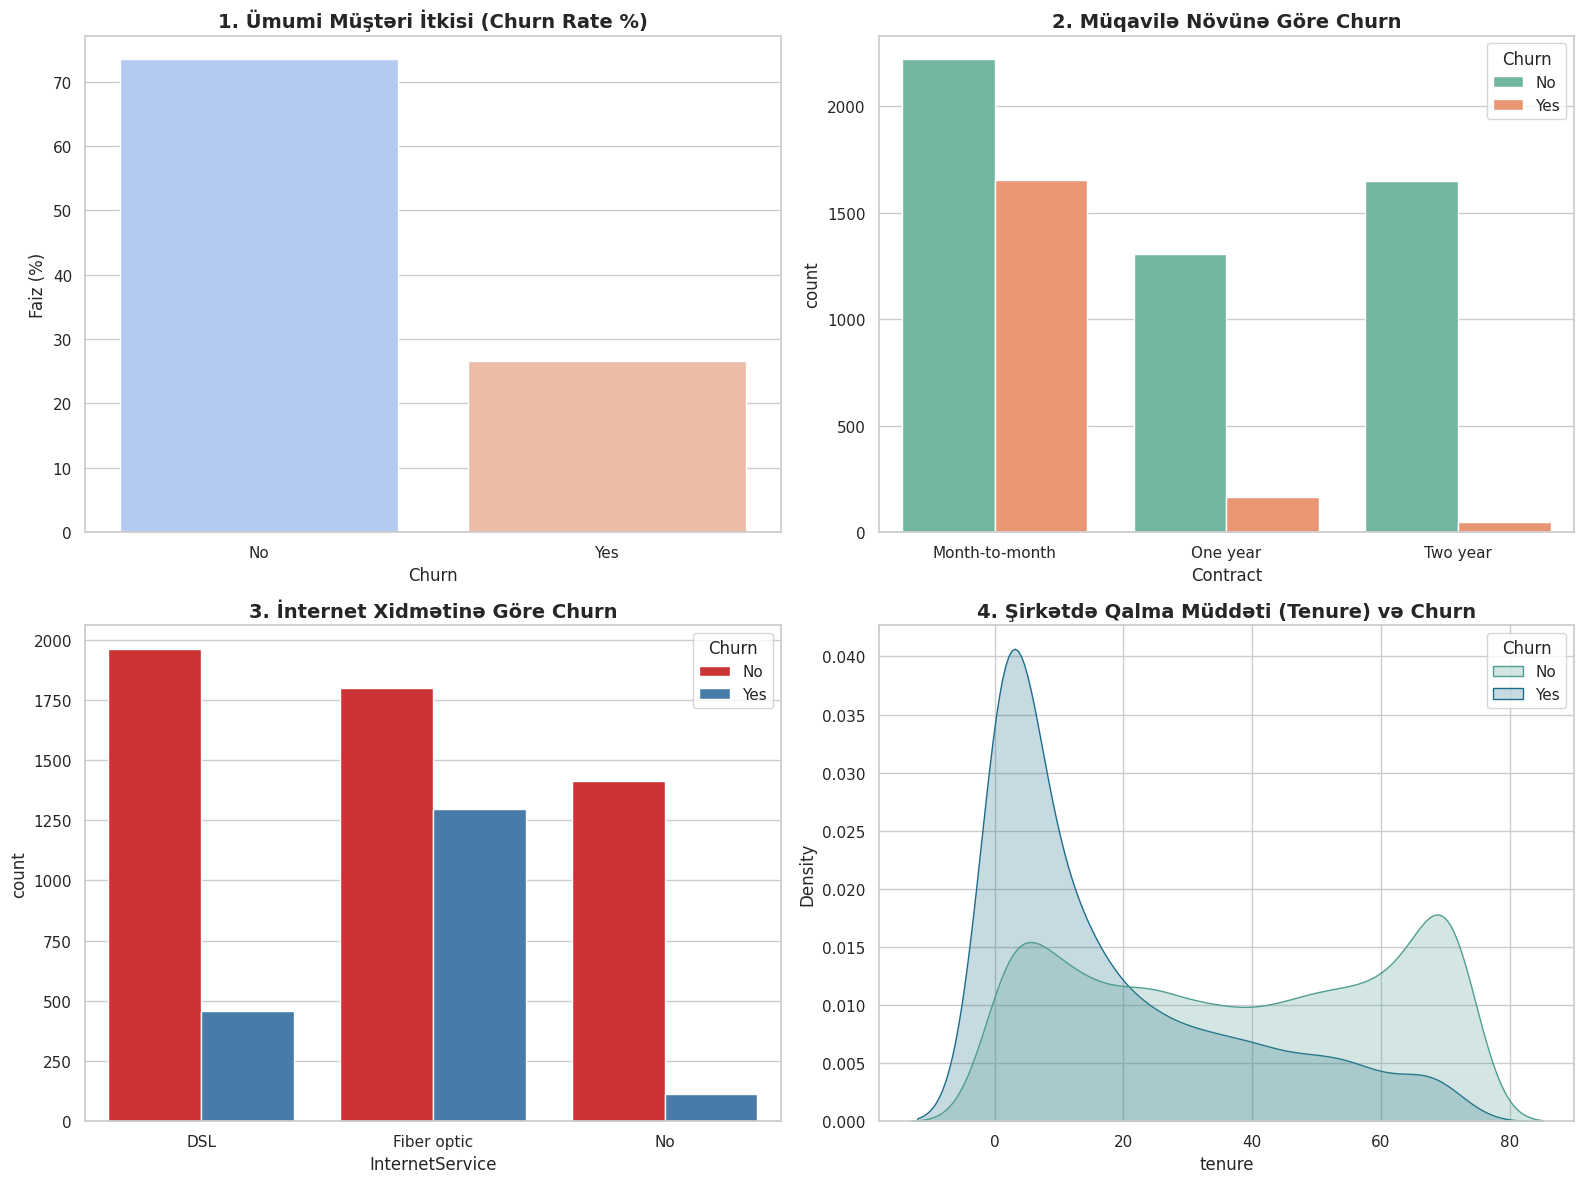

Ümumi Churn Nisbəti: 26.5%
Aylıq müqaviləsi olanların Churn faizi: 42.7%


In [11]:
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

churn_rate = df['Churn'].value_counts(normalize=True) * 100
sns.barplot(x=churn_rate.index, y=churn_rate.values, ax=axes[0, 0], palette="coolwarm")
axes[0, 0].set_title("1. Ümumi Müştəri İtkisi (Churn Rate %)", fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel("Faiz (%)")

sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("2. Müqavilə Növünə Göre Churn", fontsize=14, fontweight='bold')

sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[1, 0], palette="Set1")
axes[1, 0].set_title("3. İnternet Xidmətinə Göre Churn", fontsize=14, fontweight='bold')

sns.kdeplot(data=df, x='tenure', hue='Churn', common_norm=False, fill=True, ax=axes[1, 1], palette="crest")
axes[1, 1].set_title("4. Şirkətdə Qalma Müddəti (Tenure) və Churn", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Ümumi Churn Nisbəti: {df['Churn_Numeric'].mean()*100:.1f}%")
print("Aylıq müqaviləsi olanların Churn faizi:", 
      f"{df[df['Contract']=='Month-to-month']['Churn_Numeric'].mean()*100:.1f}%")

# 📊 Executive Summary & Business Recommendations

### Key Insights:
1. **High Churn Rate:** Overall customer churn rate stands at **26.5%**.
2. **Contract Type Impact:** Customers with a **Month-to-month** contract have a significantly higher churn risk compared to long-term contracts.
3. **Tenure Critical Window:** Highest churn occurs within the **first 12 months** of subscription.

### Business Action Plan:
* **Incentivize Long-term Contracts:** Offer discounts or perks for switching from monthly to 1-year/2-year plans to increase customer retention.
* **Onboarding Support:** Focus marketing and support efforts on new customers during their first 6 months to reduce early drop-offs.
* **Fiber Optic Review:** Investigate customer satisfaction and pricing strategy for Fiber Optic internet services, as churn is surprisingly high in this category.